In [99]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from dataclasses import dataclass

In [79]:

data = [10, 7, 6, 5, 2, 2, 3, 4]
data = [10, 3, 2, 7, 2, 7, 2, 7, 7]

$a = 3$

$b = 1$

$c = \sqrt{a^2 + b^2}$

$sin(\alpha) = \frac{a}{c}$

In [94]:
def get_angles(distance: int, height: int) -> float:
    return np.degrees(np.arcsin(height/np.sqrt(height**2 + distance**2)))

def load_topology(path: str) -> np.ndarray:
    img = Image.open(path)
    return np.array(img)

def bresenham_line(x0, y0, x1, y1):
    points = []
    
    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    
    x, y = x0, y0
    
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    
    if dx > dy:
        err = dx / 2.0
        while x != x1:
            points.append((x, y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
    else:
        err = dy / 2.0
        while y != y1:
            points.append((x, y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy

    points.append((x1, y1))
    return points

In [81]:
print(get_angles(1, 3))

71.56505117707799


In [82]:
x = []
smallest_angle = 90

for i in range(1, len(data)):
    angle = get_angles(i, data[0]-data[i])
    if angle < smallest_angle:
        smallest_angle = angle
        x.append(True)
    else:
        x.append(False)

print(x)

[True, True, True, False, True, False, True, True]


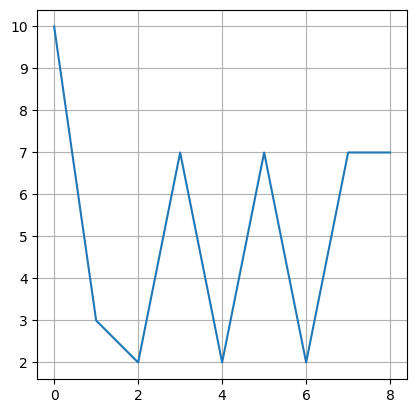

In [83]:
fig, ax = plt.subplots()
ax.plot(data)
ax.set_aspect('equal')
ax.grid(True)
plt.show()

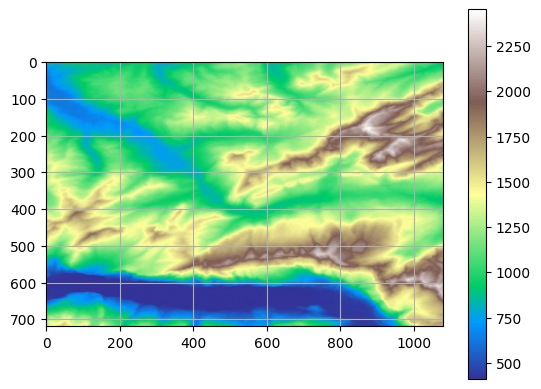

In [127]:
topology = load_topology("/home/lzimmermann/projects/SkyLineSight/output/topologie/output_SRTMGL1.tif")

plt.imshow(topology, cmap="terrain", vmin=topology.min(), vmax=topology.max())
plt.colorbar()
plt.grid()
plt.show()

In [93]:
print(topology.shape)
print(topology.min(), topology.max())
print(topology[0, 0], topology[0, 1], topology[0, 2])

(720, 1080)
411 2453
756 762 767


In [128]:
start = (750, 450)
end = (800, 500)

coordinates_points = bresenham_line(start[0], start[1], end[0], end[1])

In [129]:
@dataclass
class Coordinate:
    x: int
    y: int
    height: int
    is_visible: list[bool]
    distance: float

In [132]:
print(len(coordinates_points))

coordinates = {}
smallest_angle = 90

for coord in coordinates_points:
    distance = np.sqrt((coord[0]-start[0])**2 + (coord[1]-start[1])**2)
    angle = get_angles(distance, topology[coord[1], coord[0]]-topology[start[1], start[0]])

    if angle < smallest_angle:
        smallest_angle = angle
        is_visible = True
    else:
        is_visible = False

    coordinates[coord] = Coordinate(
        x=coord[0],
        y=coord[1],
        height=topology[coord[1], coord[0]],
        is_visible=[is_visible],
        distance=distance
    )

51


/tmp/ipykernel_295074/4186016705.py:2: RuntimeWarning: invalid value encountered in scalar divide
  return np.degrees(np.arcsin(height/np.sqrt(height**2 + distance**2)))


Text(0, 0.5, 'Height')

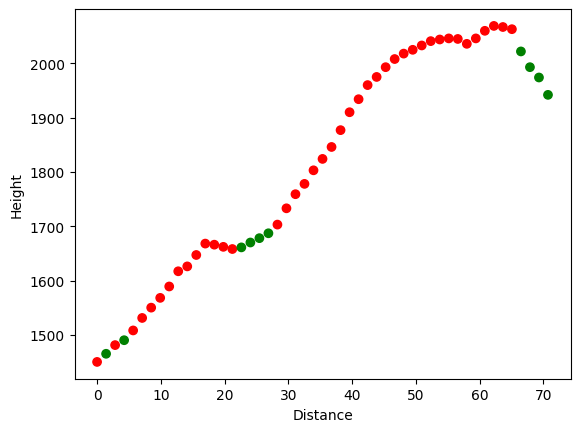

In [ ]:
distance = []
height = []

for c in coordinates.values():
    distance.append(c.distance)
    height.append(c.height)

plt.scatter(distance, height, c=['green' if c.is_visible[0] else 'red' for c in coordinates.values()])
plt.grid()
plt.xlabel('Distance')
plt.ylabel('Height')